In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the raw data
df = pd.read_csv("Unemployment in India.csv")

# Inspect the first few rows
print(df.head())
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data colu

In [2]:
# Clean : Title case and remove whitespace
df.columns = df.columns.str.strip()
df['Region'] = df['Region'].str.title().str.strip()
df['Frequency'] = df['Frequency'].str.title().str.strip()
df['Area'] = df['Area'].str.title().str.strip()
print(df.head())

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  


In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract month name into a new 'Month' column
df['Month'] = df['Date'].dt.strftime('%b')

print(df.head())

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area Month  
0          11999139.0                                    43.24  Rural   May  
1          11755881.0                                    42.05  Rural   Jun  
2          12086707.0                                    43.50  Rural   Jul  
3          12285693.0                                    43.97  Rural   Aug  
4          12256762.0                                    44.68  Rural   Sep  


In [4]:
print("Missing values before dropping rows:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing values after dropping rows:")
print(df.isnull().sum())

# Inspect the first few rows to confirm changes
print(df.head())

Missing values before dropping rows:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
Month                                      28
dtype: int64

Missing values after dropping rows:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
Month                                      0
dtype: int64
           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019

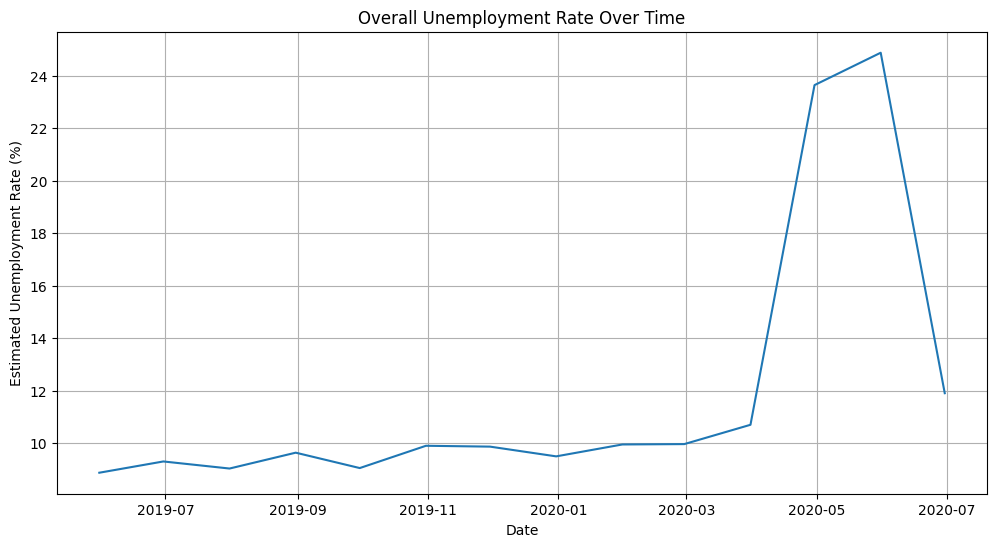

In [5]:
# Overall Unemployment Rate Over Time
overall_unemployment_rate_df = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=overall_unemployment_rate_df, x='Date', y='Estimated Unemployment Rate (%)')
plt.title('Overall Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

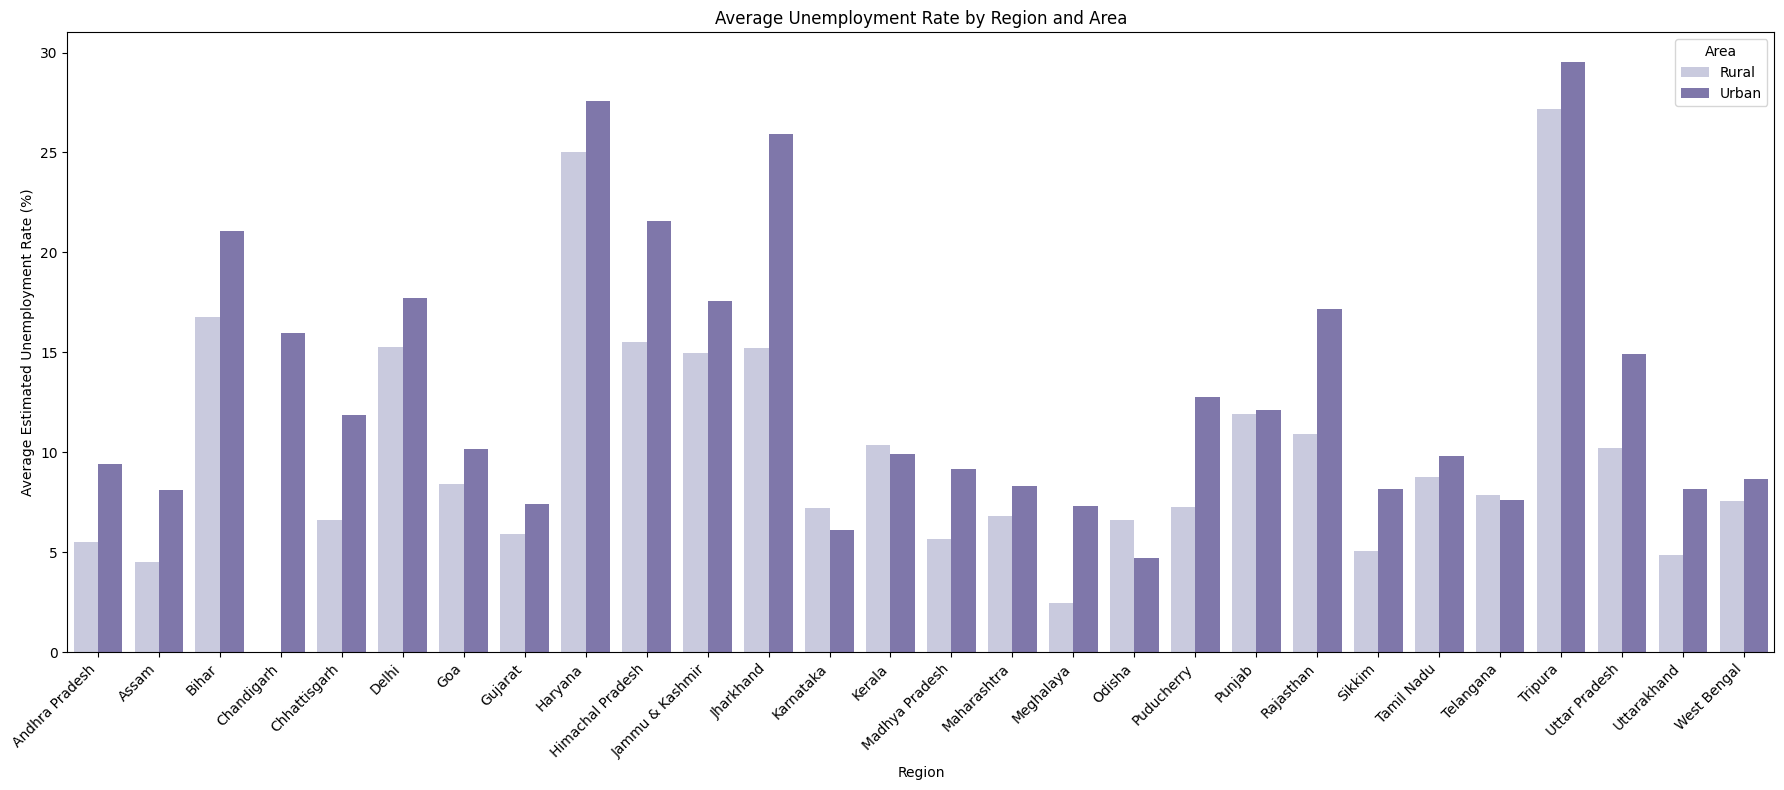

In [6]:
# Average Unemployment Rate by Region and Area
region_area_unemployment_df = df.groupby(['Region', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(18, 8))
sns.barplot(data=region_area_unemployment_df, x='Region', y='Estimated Unemployment Rate (%)', hue='Area', palette='Purples')
plt.title('Average Unemployment Rate by Region and Area')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Area')
plt.tight_layout()
plt.show()

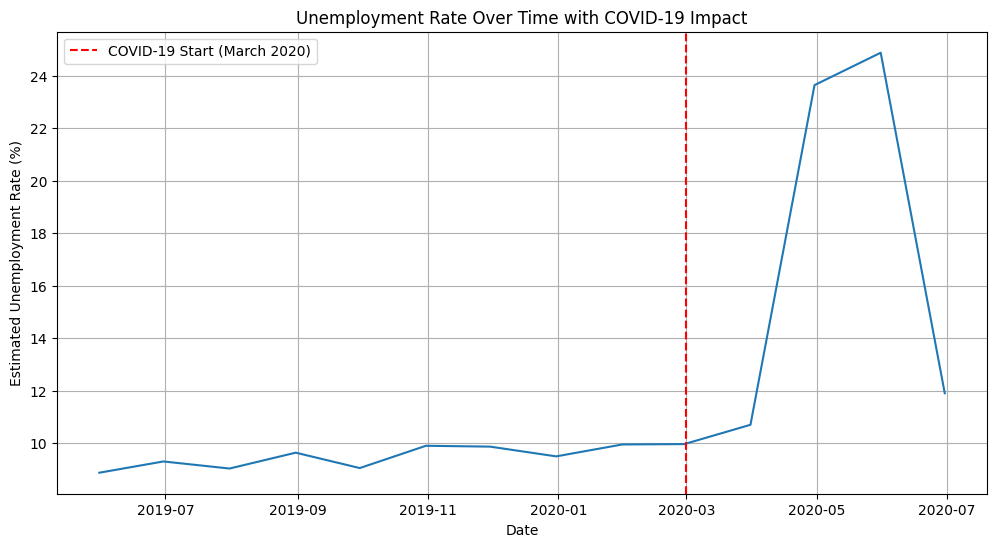

In [7]:
# Unemployment Rate Over Time with COVID-19 Impact
covid_start_date = pd.to_datetime('2020-03-01')

plt.figure(figsize=(12, 6))
sns.lineplot(data=overall_unemployment_rate_df, x='Date', y='Estimated Unemployment Rate (%)')
plt.axvline(x=covid_start_date, color='red', linestyle='--', label='COVID-19 Start (March 2020)')
plt.title('Unemployment Rate Over Time with COVID-19 Impact')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

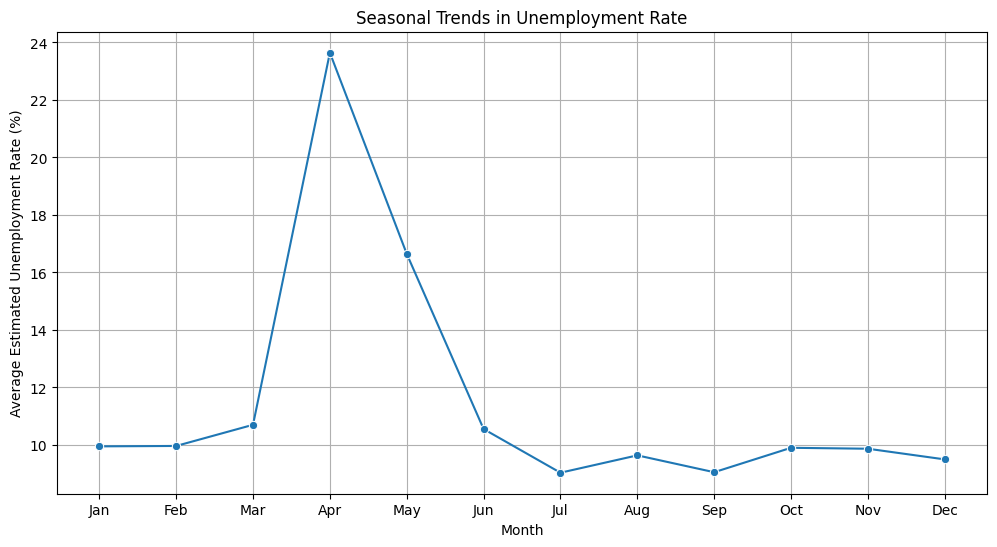

In [8]:
# Seasonal Trends in Unemployment Rate
monthly_unemployment_df = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Define a specific order for months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_unemployment_df['Month'] = pd.Categorical(monthly_unemployment_df['Month'], categories=month_order, ordered=True)
monthly_unemployment_df = monthly_unemployment_df.sort_values('Month')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_unemployment_df, x='Month', y='Estimated Unemployment Rate (%)', marker='o')
plt.title('Seasonal Trends in Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

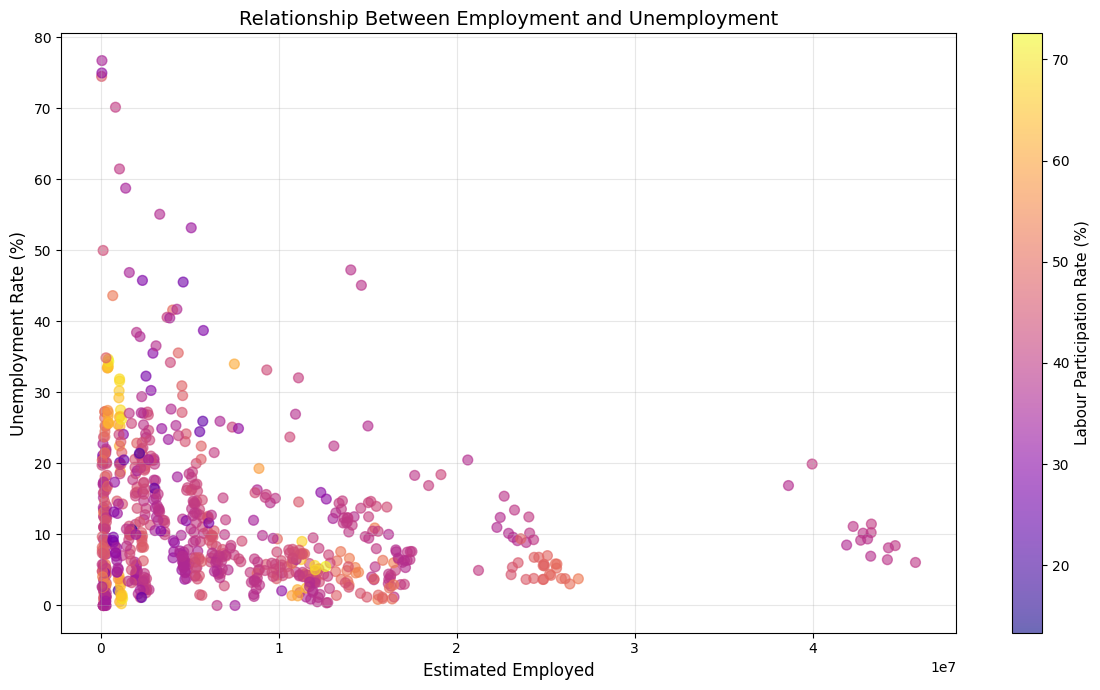

In [9]:
# Relationship Between Employment and Unemployment
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['Estimated Employed'],
                     df['Estimated Unemployment Rate (%)'],
                     alpha=0.6, s=50, c=df['Estimated Labour Participation Rate (%)'],
                     cmap='plasma')
plt.xlabel('Estimated Employed', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.title('Relationship Between Employment and Unemployment', fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Labour Participation Rate (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics by Region and Area Type

           Region   Area  unemployment_rate_mean  unemployment_rate_std  \
0  Andhra Pradesh  Rural                5.526429               4.344968   
1  Andhra Pradesh  Urban                9.427857               8.392775   
2           Assam  Rural                4.490833               2.096098   
3           Assam  Urban                8.088571               2.692842   
4           Bihar  Rural               16.770000              12.843814   

   employed_mean  employed_std  labour_participation_mean  \
0   1.180859e+07  1.519086e+06                  42.963571   
1   4.499592e+06  6.737560e+05                  35.787857   
2   9.716618e+06  1.316475e+06                  47.072500   
3   1.616048e+06  8.977238e+04                  42.979286   
4   2.184369e+07  3.315976e+06                  38.417143   

   labour_participation_std  
0                  3.990708  
1                  2.852718  
2                  6.822961  
3                  2.411822  
4                  1.130129  


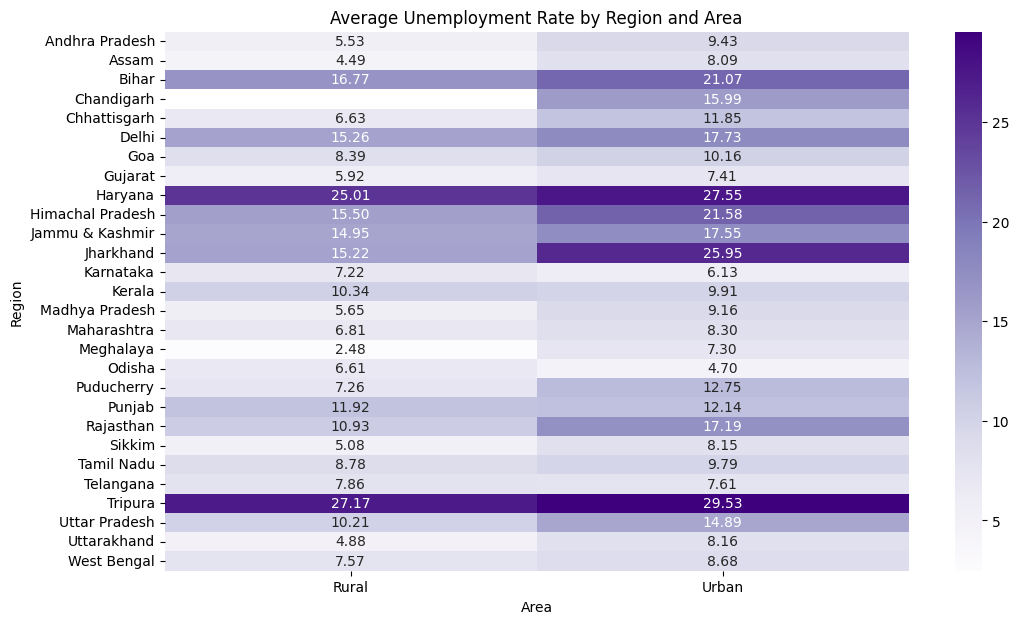

In [10]:
# Calculate summary statistics by Region and Area
summary_stats_region_area = df.groupby(['Region', 'Area']).agg(
    unemployment_rate_mean=('Estimated Unemployment Rate (%)', 'mean'),
    unemployment_rate_std=('Estimated Unemployment Rate (%)', 'std'),
    employed_mean=('Estimated Employed', 'mean'),
    employed_std=('Estimated Employed', 'std'),
    labour_participation_mean=('Estimated Labour Participation Rate (%)', 'mean'),
    labour_participation_std=('Estimated Labour Participation Rate (%)', 'std')
).reset_index()

print(summary_stats_region_area.head())

# Corrected line to create heatmap_data
heatmap_data = summary_stats_region_area.pivot_table(index='Region', columns='Area', values='unemployment_rate_mean')

plt.figure(figsize=(12,7))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Purples")

plt.title("Average Unemployment Rate by Region and Area")
plt.ylabel("Region")
plt.xlabel("Area")
plt.show()